**目标数据：MIT-BIH Arrhythmia Database（心电图（ECG）分析的鼻祖级数据）**
- 去噪(denoising):实现一个带通滤波器，切掉呼吸造成的低频漂移和肌肉造成的高频噪声
- 心拍分割(Segmentation): 找到R波的峰值，然后向左向右各取0.5s，把连续的信号切成一个个单独的心跳片段

In [41]:
import wfdb
import os
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import find_peaks
import numpy as np

**数据下载**

In [3]:
download_dir = './data/'

print('start downloading data...')
wfdb.dl_database('mitdb',dl_dir=download_dir,records=['100'])

start downloading data...
Generating record list for: 100
Generating list of all files for: 100
Finished downloading files


**读取并查看元数据**

In [4]:
# wfdb.rdrecord() 参数：文件路径，不需要加后缀（.hat），只需要写到文件名
record = wfdb.rdrecord('./data/100')

# 打印关键信息
# record 对象里有很多属性，最重要的就是 fs (采样率) 和 sig_len (信号长度)
print(f'''
信号名称：{record.record_name}
采样率：{record.fs} HZ
信号总长度：{record.sig_len}
包含的导联：{record.sig_name}
''')

# 看信号数据本身
# 信号数据储存在 record.p_signal 中，它是一个 numpy 矩阵
print(f'数据形状：{record.p_signal.shape}')



信号名称：100
采样率：360 HZ
信号总长度：650000
包含的导联：['MLII', 'V5']

数据形状：(650000, 2)


1. .dat (Data / 数据本体)
這是真正的信号文件。它是二进制格式（Binary），里面全是数字。
形象比喻： 就像一盘磁带，里面录的是声音（电压值），但没有任何标签。如果你直接打开它，只会看到一堆乱码。

2. .hea (Header / 头文件)
这是“说明书”。它告诉程序：采样率是多少？电压单位是什么？第一列是哪个导联？没有它，.dat 就是一堆废数据。
作用： 刚才代码打印出来的 360 Hz 和 MLII 等信息，其实都是 wfdb 帮读取了这个文件告诉你的。

3. .atr (Attribute / 注释文件)
这是**“标准答案”**（Ground Truth）。
最关键： 这是由专业的心脏科医生一个个点出来的标签。它标记了每一个心跳的 R 波位置，以及这个心跳是“正常 (Normal)”还是“早搏 (PVC)”。我们后面训练 AI，就是要让 AI 去学习这个文件里的标注。

1. 心电信号的主要频率集中在0.5HZ到100HZ之间，根据奈奎斯特采样定理，采样率至少要是最高频率的2倍（200HZ），这里360HZ能保留非常清晰的波形细节
2. 信号总长度 650000 / 360 = 1805 seconds
3. MLII (Modified Lead II,改良II导联) 它平行与心脏的电轴（右上到左下），看到R波最清楚，通常用于识别心率失常，这是我们需要重点关注的
4. V5（胸导联）侧面视角，通常用于看到心肌缺血（ST段抬高/压低），在心率分布中起辅助作用

**心电图的基本单元：P-QRS-T 波群：**
1. P 波：表示心房收缩，一个小土包
2. QRS 波群： 一个尖峰
    - 心室剧烈收缩
    - 最高的峰叫 R 波
    - 我们后续的分析，第一步都是要先找到这个 R 波
3. T 波：心室舒张，准备下一次跳动，一个中等土包

**心率失常**

**室性早搏：** 没有 P 波，QRS 波变得非常宽大畸形，而且提前跳了一下

**画心电图**
- 取数
- 切片
- 绘图

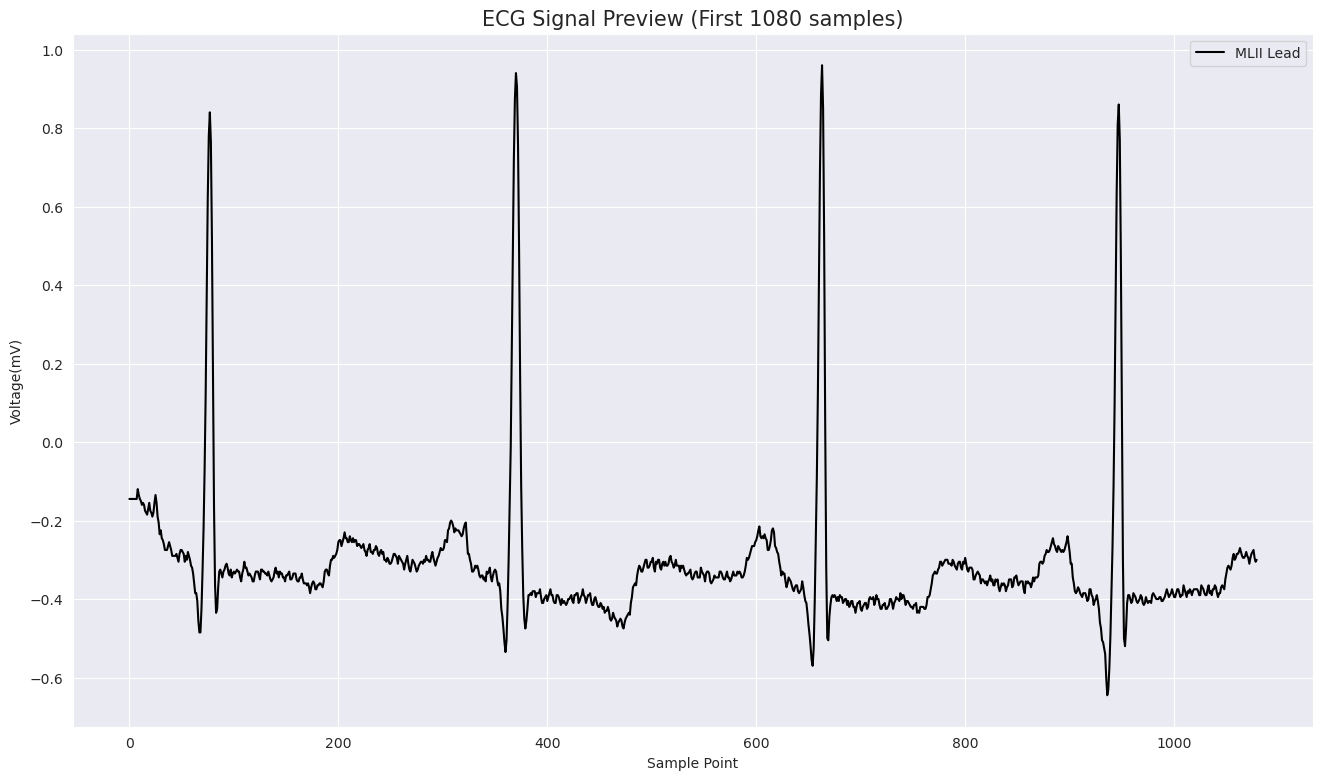

In [16]:
# 提取数据
record_ml2 = record.p_signal[:,0]

# 切片，看前3秒左右的数据
record_ml2_pre3 = record_ml2[0:1080]

# 绘图
# 设置画布
fig = plt.figure(figsize=(16,9),dpi=100,)
# 画图指令
plt.plot(record_ml2_pre3,color='black',label='MLII Lead')
# 加标签
plt.title('ECG Signal Preview (First 1080 samples)',fontsize=15)
plt.xlabel('Sample Point')
plt.ylabel('Voltage(mV)')
plt.legend()
# 加网格
plt.grid(True)

1. **基线漂移 (Baseline Wander):** 注意看波形的底部。它不是贴在 0 电压的一条直线上，而是像波浪一样忽上忽下（第 200 点附近偏低，第 700 点附近又偏低）。
- 病人的呼吸。呼吸会让电极贴片随着胸廓起伏，导致电压基准线移动。
2. **高频毛刺 (High Frequency Noise):** 线条本身并不光滑，有很多锯齿。
- 肌电干扰（肌肉微颤）或工频干扰（电源线辐射）。

#### 数字滤波
- 切掉低频( <0.5 Hz): 去除呼吸漂移
- 切掉高频( >50 Hz): 去除肌电和电源噪音
- 保留中频( 0.5 - 50 Hz): 心脏电生理活动的频率

In [27]:
# 设定参数
fs = 360
lowcut = 0.5
highcut = 50.0
order = 2

# 计算归一化频率
nyq = 0.5 * fs
low = lowcut / nyq
high = highcut / nyq

# 设计滤波器
b,a = signal.butter(order,[low,high],btype='bandpass')

# 执行滤波（零相位滤波）
clean_signal_pre3 = signal.filtfilt(b,a,record_ml2_pre3)
clean_signal = signal.filtfilt(b,a,record_ml2)

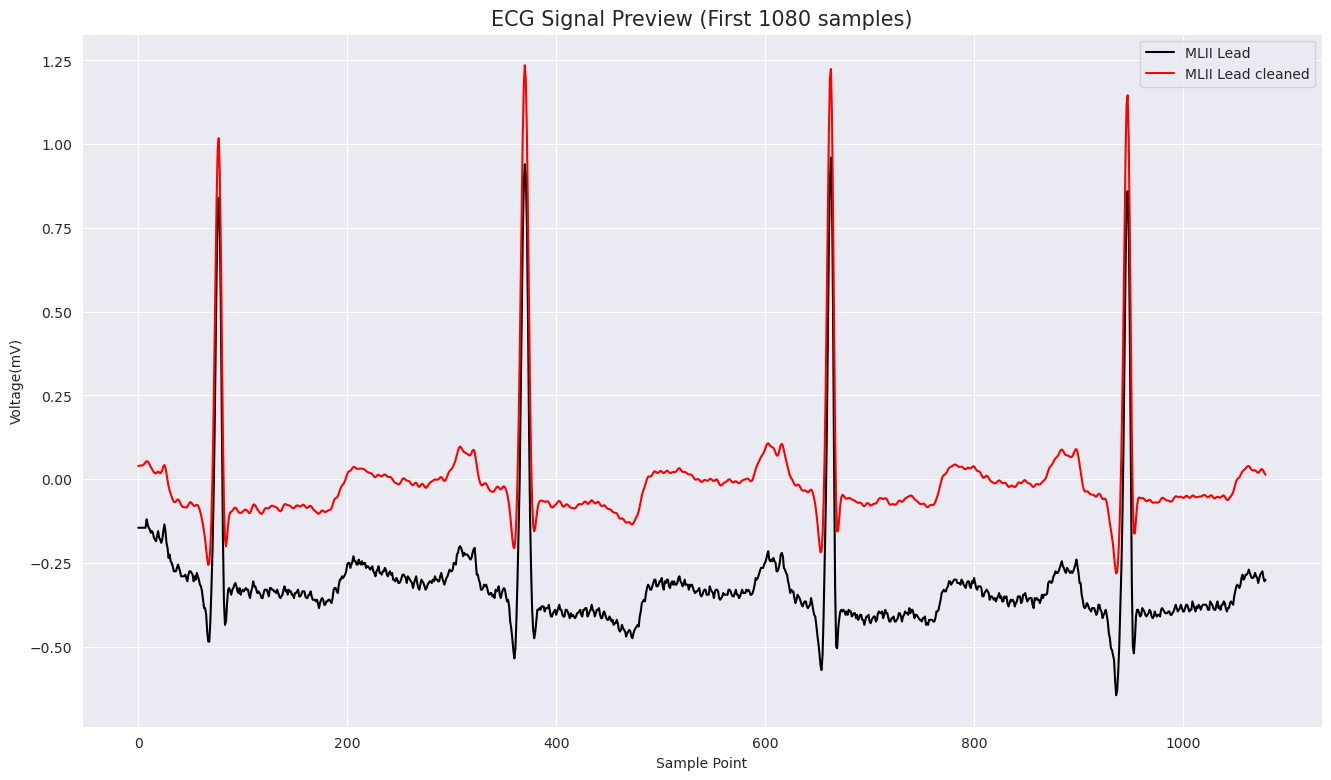

In [39]:
fig = plt.figure(figsize=(16,9),dpi=100,)
# 画图指令
plt.plot(record_ml2_pre3,color='black',label='MLII Lead')
plt.plot(clean_signal_pre3,color='red',label='MLII Lead cleaned')
# 加标签
plt.title('ECG Signal Preview (First 1080 samples)',fontsize=15)
plt.xlabel('Sample Point')
plt.ylabel('Voltage(mV)')
plt.legend()
# 加网格
plt.grid(True)

#### 心拍分割
- 识别R峰
- 以R峰为中心前后各0.5s

这里共找到了 2273 次心跳


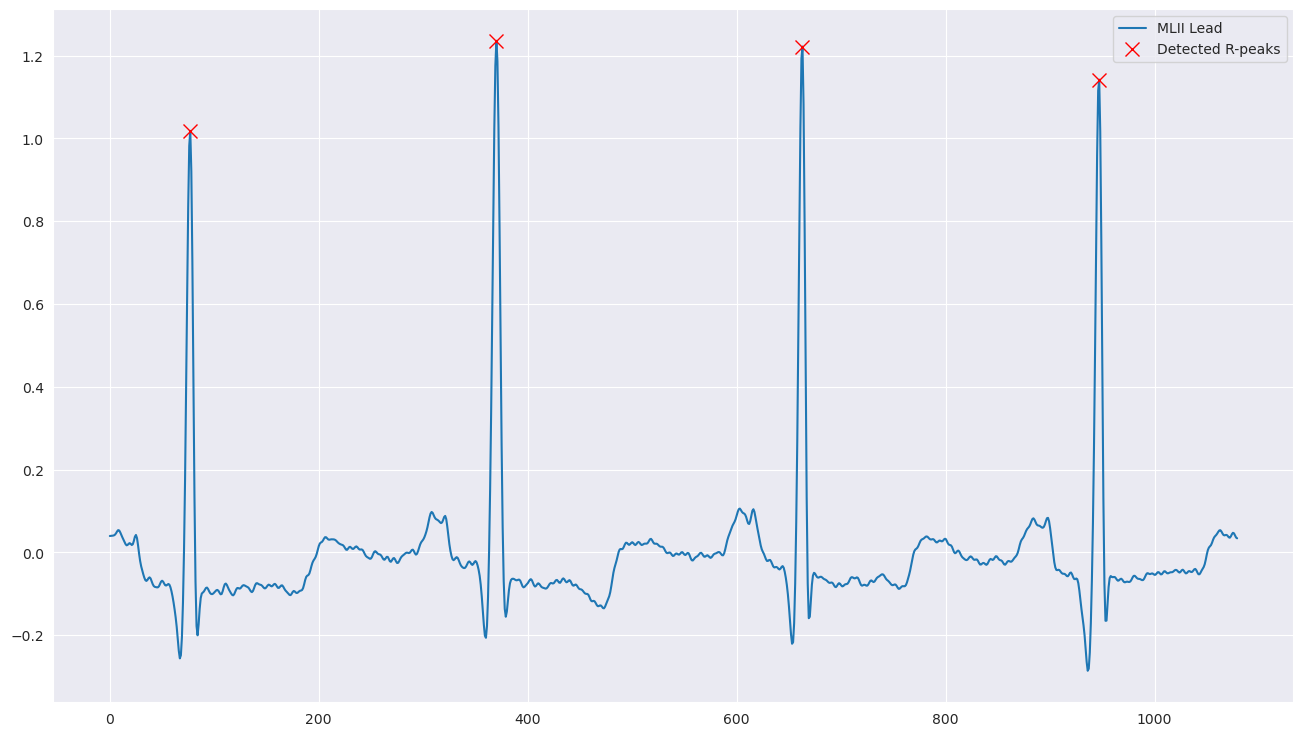

In [40]:
# 寻找峰值
r_peak, _ = find_peaks(clean_signal,height=0.5,distance=150)
print(f'这里共找到了 {len(r_peak)} 次心跳')

# 可视化验证
plt.figure(figsize=(16,9),dpi=100,)
plt.plot(clean_signal[:1080],label='MLII Lead')

valid_peaks = r_peak[r_peak < 1080 ]

plt.plot(valid_peaks,clean_signal[valid_peaks],'x',color='r',markersize=10,label='Detected R-peaks')

plt.legend()

1. 确定切割窗口
- 向左取 90 个点 (0.25秒)，向右取 210 个点 (约0.6秒)。
- 为什么右边要多一点？ 因为 T 波在 R 波后面，而且有时候 QT 间期会延长，多留点余地能保证把 T 波完整包进去。
- 总长度: 300 个点。
2. 边界处理
- 第一次心跳: 如果它的位置在第 50 个点，向左切 90 个点就会切到负数索引（报错）。
- 最后一次心跳: 同理，可能会切出数组边界。
- 对策: 遇到这种“掐头去尾”的情况，直接丢弃，不切。

切片完成，最终数据形状(2271, 300)


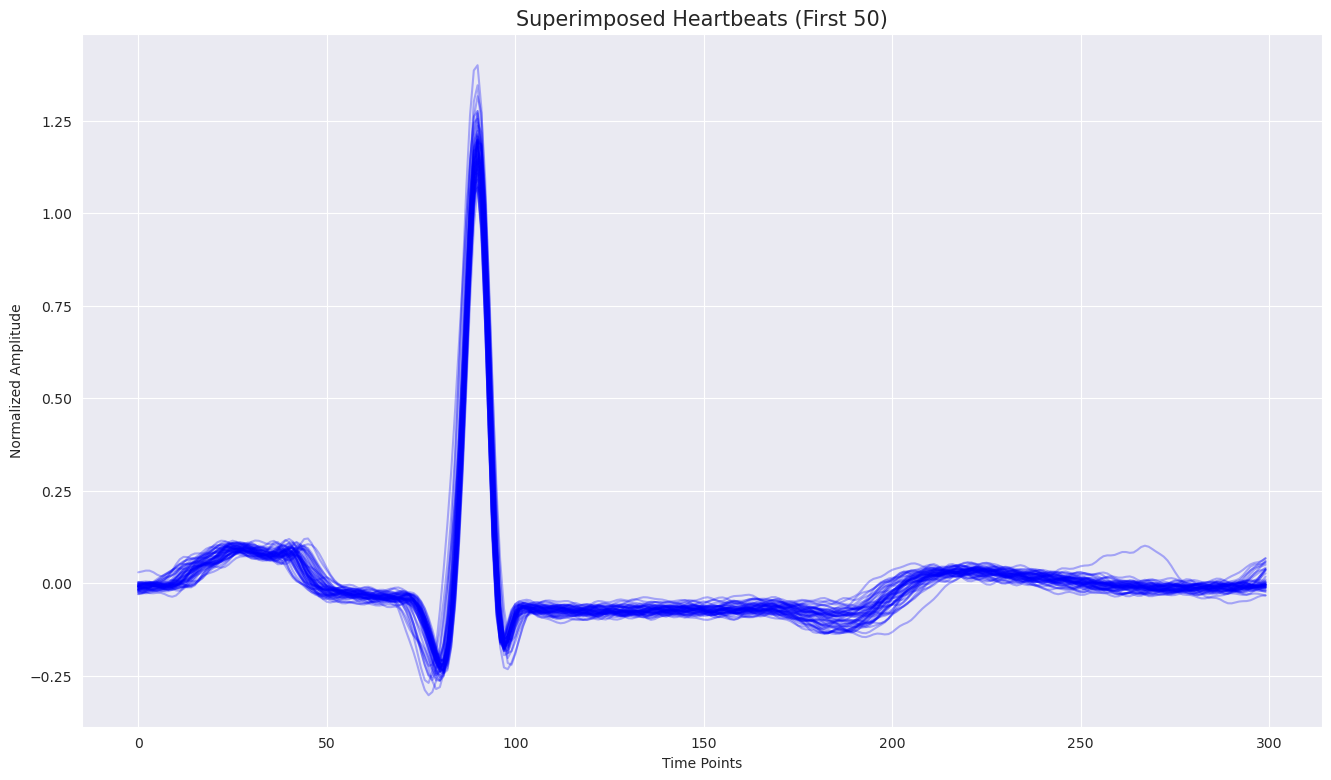

In [43]:
# 设置参数
window_left = 90
window_right = 210

segments = []    # 用来装切割好的心跳

# 切割循环
for r in r_peak:
    # 划定切片位置
    start = r - window_left
    end = r + window_right

    # 边界检查
    if start < 0 or end > len(clean_signal):
        continue

    # 切片并存入列表
    segment = clean_signal[start:end]
    segments.append(segment)

# 转换格式
X_data = np.array(segments)
print(f'切片完成，最终数据形状{X_data.shape}')

# 视觉验证
plt.figure(figsize=(16,9),dpi=100,)
# 这里需要转置一下(.T)
plt.plot(X_data[:50].T,color='blue',alpha=0.3)  # alpha=0.3 让线条透明一点，重叠起来好看
plt.title('Superimposed Heartbeats (First 50)', fontsize=15)
plt.xlabel('Time Points')
plt.ylabel('Normalized Amplitude')
plt.show()

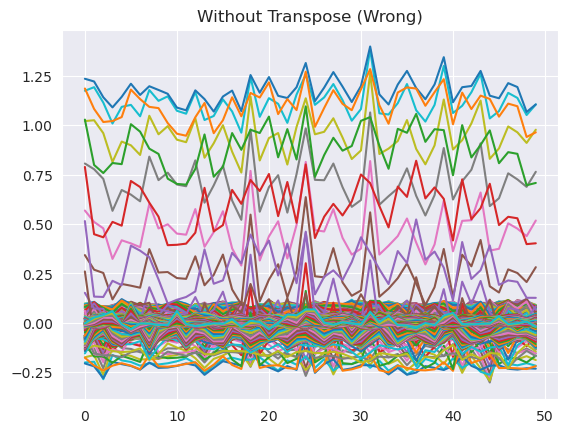

In [44]:
# 错误的画法
plt.plot(X_data[:50]) # 没加 .T
plt.title("Without Transpose (Wrong)")
plt.show()

#### 读取医生诊断（.atr）

In [45]:
# 读取注释（annotation)
# ann.sample: 标记的位置（对应R波的索引）
# ann.symbol: 标记的类型（‘N’代表正常，‘V’代表室性早搏，等等）
annotation = wfdb.rdann('./data/100','atr')

# 统计一下每种心跳有多少个
from collections import Counter
print(f'标签类别统计：{Counter(annotation.symbol)}')

# 提取与我们切片对应的标签
# 逻辑：我们的 r_peaks 是我们自己算的，annotation.sample 是医生标的
# 理论上它们应该几乎重合。为了简化，我们直接取我们切片位置对应的医生标签。

# 这里做一个简单的映射逻辑（实际工程中需要更严谨的对齐，这里做演示用）
# 我们假设我们的 R 波检测很准，直接取前 2271 个医生的标签
y_labels = annotation.symbol[:len(X_data)]

print(f"输入数据形状 (X): {X_data.shape}")
print(f"标签数据长度 (y): {len(y_labels)}")
print(f"前 10 个标签: {y_labels[:10]}")

标签类别统计：Counter({'N': 2239, 'A': 33, '+': 1, 'V': 1})
输入数据形状 (X): (2271, 300)
标签数据长度 (y): 2271
前 10 个标签: ['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N']
